<a href="https://colab.research.google.com/github/sreeja-454/demand-forecasting-for-stores/blob/main/PDNC_PBL_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
            Sales
Date             
2023-01-01    147
2023-01-02    160
2023-01-03     82
2023-01-04    143
2023-01-05    154


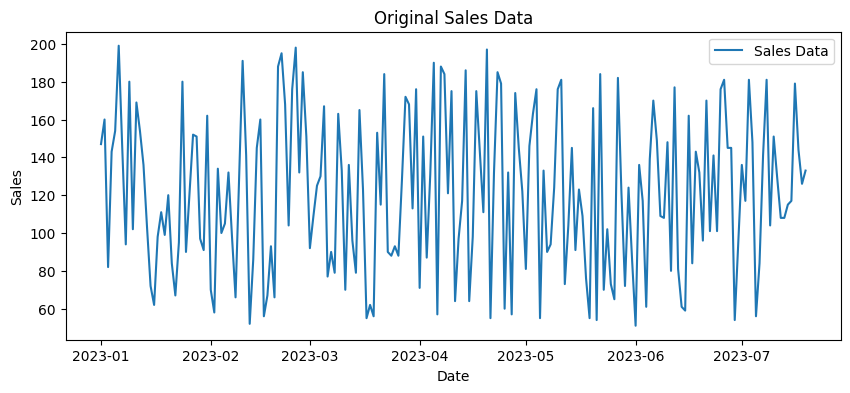


Scaled Data Sample:
[[0.64864865]
 [0.73648649]
 [0.20945946]
 [0.62162162]
 [0.69594595]]

Shape of X: (189, 10)
Shape of y: (189,)

Reshaped X shape: (189, 10, 1)

Training samples: 151
Testing samples: 38

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1785
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0935
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0889
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0854
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0868
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0880
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0845
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0868
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0843
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0843
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0843
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0843
Epoch 13/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0842
Epoch 14/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0842
Epoch 15/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0835
Epoc

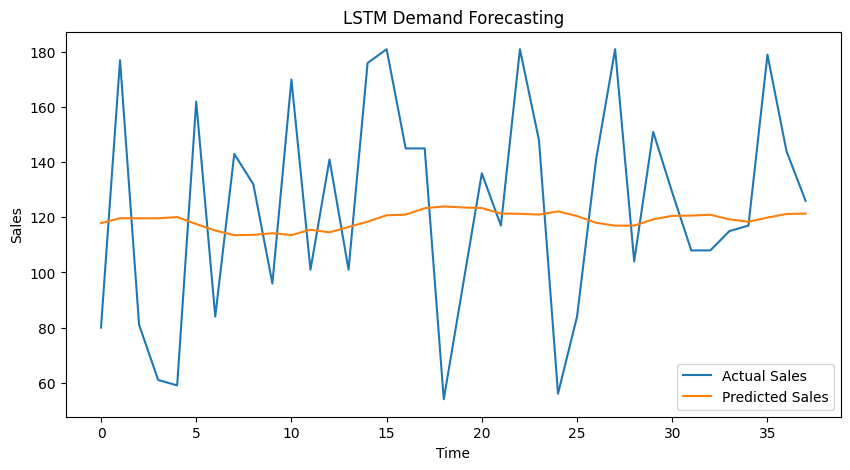

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

Next Day Predicted Demand: 121.562805


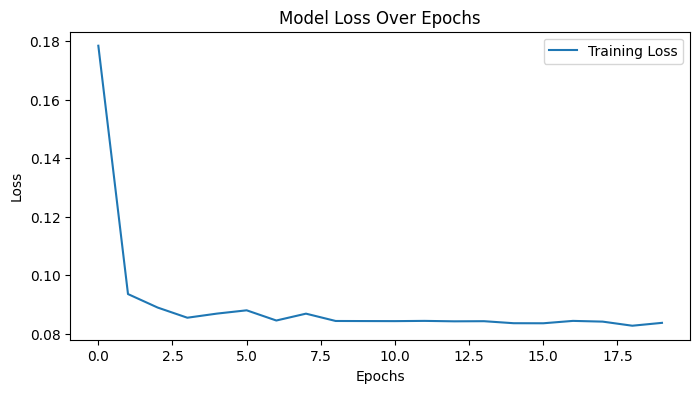

In [1]:
# -------------------------------
# STEP 1: IMPORT LIBRARIES
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------------
# STEP 2: CREATE SAMPLE DATASET
# -------------------------------

# Create date range
dates = pd.date_range(start='2023-01-01', periods=200, freq='D')

# Generate random sales data
sales = np.random.randint(50, 200, size=200)

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Sales': sales
})

# Set Date as index
df.set_index('Date', inplace=True)

# Display first 5 rows
print("Dataset Preview:")
print(df.head())

# -------------------------------
# STEP 3: VISUALIZE DATA
# -------------------------------
plt.figure(figsize=(10, 4))
plt.plot(df['Sales'], label='Sales Data')
plt.title("Original Sales Data")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# -------------------------------
# STEP 4: DATA NORMALIZATION
# -------------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

print("\nScaled Data Sample:")
print(scaled_data[:5])

# -------------------------------
# STEP 5: CREATE SEQUENCES
# -------------------------------
def create_dataset(dataset, time_step=10):
    X, Y = [], []

    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])

    return np.array(X), np.array(Y)

time_step = 10

X, y = create_dataset(scaled_data, time_step)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# -------------------------------
# STEP 6: RESHAPE DATA FOR LSTM
# -------------------------------
X = X.reshape(X.shape[0], X.shape[1], 1)

print("\nReshaped X shape:", X.shape)

# -------------------------------
# STEP 7: TRAIN-TEST SPLIT
# -------------------------------
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# -------------------------------
# STEP 8: BUILD LSTM MODEL
# -------------------------------
model = Sequential()

# First LSTM layer
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))

# Second LSTM layer
model.add(LSTM(50))

# Output layer
model.add(Dense(1))

# Compile model
model.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

print("\nModel Summary:")
model.summary()

# -------------------------------
# STEP 9: TRAIN MODEL
# -------------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    verbose=1
)

# -------------------------------
# STEP 10: PREDICTIONS
# -------------------------------
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# -------------------------------
# STEP 11: INVERSE SCALING
# -------------------------------
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# -------------------------------
# STEP 12: EVALUATION METRICS
# -------------------------------
mae = mean_absolute_error(y_test_actual, test_predict)
mse = mean_squared_error(y_test_actual, test_predict)
rmse = np.sqrt(mse)

print("\nEvaluation Results:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

# -------------------------------
# STEP 13: VISUALIZE RESULTS
# -------------------------------
plt.figure(figsize=(10, 5))

plt.plot(y_test_actual, label='Actual Sales')
plt.plot(test_predict, label='Predicted Sales')

plt.title("LSTM Demand Forecasting")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()

plt.show()

# -------------------------------
# STEP 14: FUTURE PREDICTION
# -------------------------------

# Take last 'time_step' days
last_days = scaled_data[-time_step:]

# Reshape for model
last_days = last_days.reshape(1, time_step, 1)

# Predict next day
future_prediction = model.predict(last_days)

# Convert back to original scale
future_prediction = scaler.inverse_transform(future_prediction)

print("\nNext Day Predicted Demand:", future_prediction[0][0])

# -------------------------------
# STEP 15: LOSS CURVE (OPTIONAL)
# -------------------------------
plt.figure(figsize=(8, 4))

plt.plot(history.history['loss'], label='Training Loss')

plt.title("Model Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()
